# Installations

In [ ]:
!pip install pyloudnorm
!pip install mir_eval
!pip install pyannote.audio
!pip install audiomentations
!pip install silero-vad

In [ ]:
import os
import IPython.display as ipd
import librosa
from glob import glob
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
import pyloudnorm as pyln
from scipy import signal, linalg
import sklearn
from ipywidgets import interact
import urllib
import mir_eval
from tqdm import tqdm

import torch
from pprint import pprint
from pyannote.audio import Pipeline

from sklearn import preprocessing
from sklearn import cluster
from typing import List, Tuple
%matplotlib inline

In [ ]:
!kaggle datasets download -d mfekadu/english-multispeaker-corpus-for-voice-cloning
!unzip english-multispeaker-corpus-for-voice-cloning.zip -d ../../data/

Показано результат, скорочений до останніх рядків (5000).
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_173.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_174.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_175.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_176.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_177.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_178.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_179.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_180.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_181.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_182.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_183.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/p340/p340_184.wav  
  inflating: ../../data/VCTK-Corpus/VCTK-Corpus/wav48/

# Code

In [ ]:
wave_pathes = glob(
    "../../data/VCTK-Corpus/VCTK-Corpus/wav48/*/*.wav", recursive=True
)

wave_pathes = [wave_path.replace('\\', '/') for wave_path in wave_pathes]

In [ ]:
silero, utils = torch.hub.load(repo_or_dir="snakers4/silero-vad", model="silero_vad", force_reload=True)
get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks = utils

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip


In [ ]:
SAMPLING_RATE = 16000

## Data preprocessing

First, we need to investigate how the input data can be processed to develop a system that functions effectively regardless of the input signal.

To begin with, it is essential to ensure that the loudness of all inputs is consistent, avoiding significant differences in amplitudes. To achieve this, let's analyze the average volume of the dataset and use it as the reference level.

In [ ]:
loudness_total = 0

for wave_path in tqdm(wave_pathes):
    sample_audio, sample_audio_sr = librosa.load(wave_path, sr=SAMPLING_RATE)
    meter = pyln.Meter(sample_audio_sr)
    loudness_total += meter.integrated_loudness(sample_audio)

print(f"\nAverage LUFS: {loudness_total / len(wave_pathes)}")

100%|██████████| 44242/44242 [08:04<00:00, 91.35it/s] 


Average LUFS: -24.553686655174086


We observe that the average value is -24.5 LUFS, so we will use -24.0 LUFS as the reference value.

As an example, let’s examine how the loudness of one of the recordings has changed:

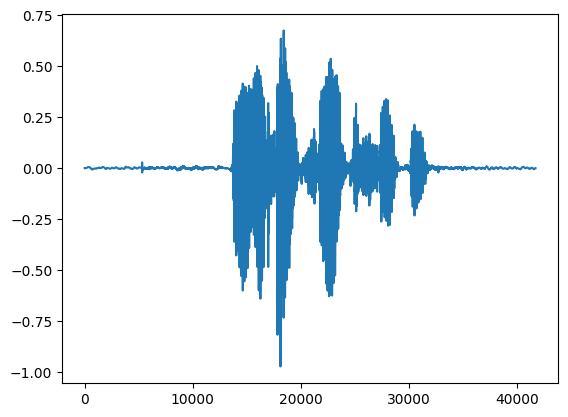

In [ ]:
sample_file = wave_pathes[0]
sample_wav = read_audio(sample_file)
sample_audio, sample_audio_sr = librosa.load(sample_file, sr=SAMPLING_RATE)
plt.plot(sample_audio)
ipd.Audio(sample_file)

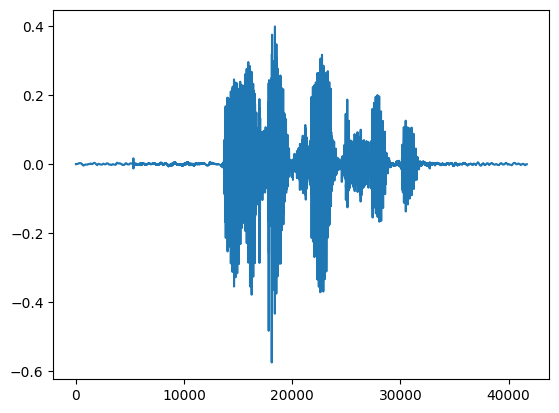

In [ ]:
meter = pyln.Meter(SAMPLING_RATE)
loudness = meter.integrated_loudness(sample_audio)
loudness_normalized_audio = pyln.normalize.loudness(sample_audio, loudness, -24.0)
sf.write("temp.wav", data=loudness_normalized_audio, samplerate=SAMPLING_RATE)
plt.plot(loudness_normalized_audio)
ipd.Audio("temp.wav")

By normalizing the temporal signal, certain frequencies can be removed. Since the human voice has a harmonic frequency range of approximately 100–4000 Hz, with the most significant energy typically concentrated between 1000–2000 Hz, frequencies outside this range are unnecessary and may interfere with the algorithm. Therefore, using Low-pass and High-pass filters, we will remove all frequencies below 100 Hz and above 3000 Hz.

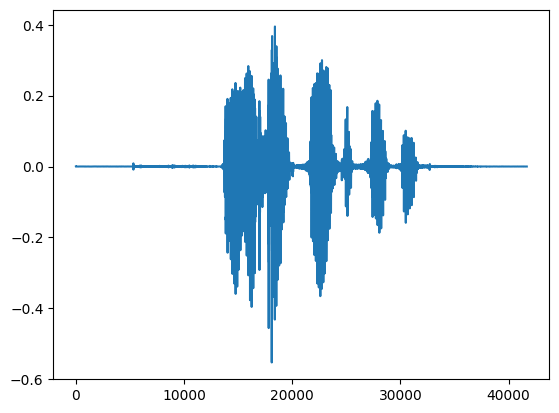

In [ ]:
cutoff_freq = 3000
order = 4

nyquist = 0.5 * SAMPLING_RATE
normal_cutoff = cutoff_freq / nyquist
b, a = signal.butter(order, normal_cutoff, btype='lowpass')

filtered_audio = signal.filtfilt(b, a, loudness_normalized_audio)

cutoff_freq = 100
normal_cutoff = cutoff_freq / nyquist
b, a = signal.butter(order, normal_cutoff, btype='high')

filtered_audio = signal.filtfilt(b, a, filtered_audio)


sf.write("temp.wav", data=filtered_audio, samplerate=SAMPLING_RATE)
plt.plot(filtered_audio)
ipd.Audio("temp.wav")

We can observe that the intervals with silence now have nearly the same amplitude, indicating that the recording has been successfully cleaned of noise.

## Feature extraction

Now that the input data has been prepared, we can proceed to building an algorithm for voice detection. During the lecture, we discussed two key features: Zero-Crossing Rate and Short-Term Energy. I suggest analyzing the values these features provide for the input data and exploring how this information can be utilized.

In [ ]:
def extract_features(x):
    zcr = librosa.zero_crossings(x).sum()
    energy = linalg.norm(x)
    return [zcr, energy]

In [ ]:
zcr_vals = []
energy_vals = []
window_size = 800
for i in range(len(filtered_audio)):
    zcr, energy = extract_features(filtered_audio[max(i - window_size, 9):min(i + window_size, len(filtered_audio))])
    zcr_vals.append(zcr)
    energy_vals.append(energy)

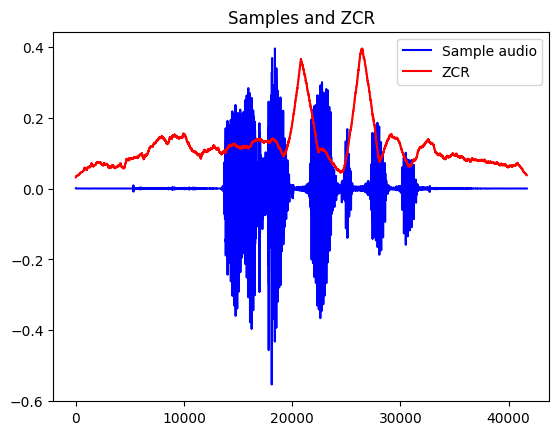

In [ ]:
x = [i for i in range(len(filtered_audio))]
y1 = filtered_audio
y2 = np.array(zcr_vals) / (max(zcr_vals) / max(filtered_audio))

plt.plot(x, y1, label="Sample audio", color="blue")
plt.plot(x, y2, label="ZCR", color="red")

plt.title("Samples and ZCR")
plt.legend()

We can observe that the Zero-Crossing Rate (ZCR) yields relatively high values regardless of whether the interval contains voice or silence, with peaks occurring only when the amplitudes decrease. Therefore, I do not see significant utility in this feature for voice detection.

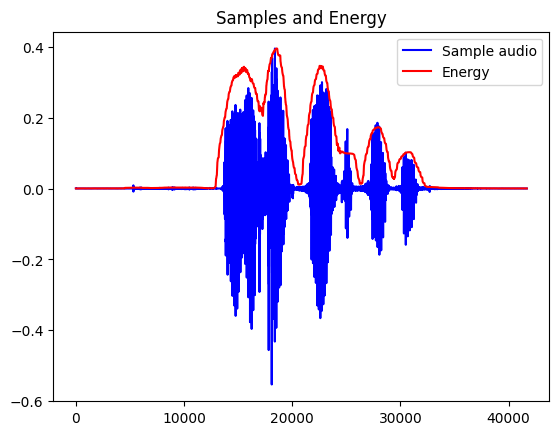

In [ ]:
x = [i for i in range(len(filtered_audio))]
y1 = filtered_audio
y2 = np.array(energy_vals) / (max(energy_vals) / max(filtered_audio))

plt.plot(x, y1, label="Sample audio", color="blue")
plt.plot(x, y2, label="Energy", color="red")

plt.title("Samples and Energy")
plt.legend()

Here, we can observe that the Short-Term Energy closely follows the silhouette of the frequency distribution, making it easy to determine whether the current interval contains sound or silence. Now, let’s overlay Silero’s prediction on the graph and establish a potential threshold to determine whether sound is present at the current value.

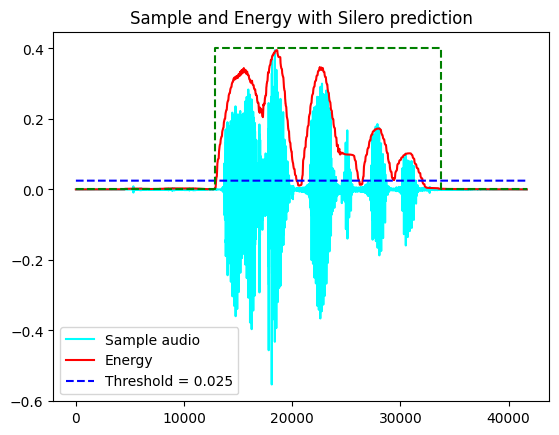

In [ ]:
speech_timestamps = get_speech_timestamps(sample_wav, silero)
intervals = [(dic["start"], dic["end"]) for dic in speech_timestamps]

x = [i for i in range(len(filtered_audio))]
y1 = filtered_audio
y2 = np.array(energy_vals) / (max(energy_vals) / max(filtered_audio))
y3 = np.array([1 for _ in range(len(x))]) * 0.025

t_binary = [0, intervals[0][0] - 1, intervals[0][0], intervals[0][1], intervals[0][1] + 1, len(x) - 1]
binary_values = np.array([0, 0, 1, 1, 0, 0]) * 0.4

plt.plot(x, y1, label="Sample audio", color="cyan")
plt.plot(x, y2, label="Energy", color="red")
plt.plot(x, y3, label="Threshold = 0.025", color="blue", linestyle="dashed")
plt.step(t_binary, binary_values, color="green", linestyle="dashed")

plt.title("Sample and Energy with Silero prediction")
plt.legend()

The high energy values align almost entirely with the intervals predicted by Silero, except at the end, where Silero predicted a slightly larger interval. However, I consider this to be a good result, so we will use it as the foundation for the algorithm.

## VAD

The algorithm will consist of three steps:
1. Preprocessing of input data
2. Calculation of Short-Term Energy
3. Search for all possible intervals

The first two steps build on the ideas discussed earlier. During the interval search, the algorithm combines all consecutive sample values greater than the threshold into a single interval. It then merges intervals if the pause between them is less than 300 milliseconds, which accounts for small gaps in speech. Finally, all intervals are checked to ensure their length exceeds the minimum duration of a spoken word, set here to 200 milliseconds. At the end, the code converts the result into the same format as Silero's output. Additionally, the code includes functionality to visually compare our predictions with those of Silero.

In [ ]:
class MyVAD:
    def __init__(self, sr: int = 16000, lufs: float = -24.0, energy_threshold: float = 0.025) -> None:
        self.sr = sr
        self.lufs = -24.0
        self.e_threshold = energy_threshold
        self.pause = self.sr * 0.3
        self.speech_len = self.sr * 0.2


    def __get_energy(self, x: np.array) -> float:
        return linalg.norm(x)


    def __filtering(self, sample: np.array, cutoff_freq: int, btype: str) -> np.array:
        nyquist = 0.5 * self.sr
        normal_cutoff = cutoff_freq / nyquist

        b, a = signal.butter(4, normal_cutoff, btype=btype)
        filtered_audio = signal.filtfilt(b, a, sample)
        return filtered_audio


    def __preprocess_sample(self, sample: np.array) -> np.array:
        meter = pyln.Meter(SAMPLING_RATE)
        input_loudness = meter.integrated_loudness(sample)
        loudness_normalized_audio = pyln.normalize.loudness(sample, input_loudness, self.lufs)

        lowpass_filtered_audio = self.__filtering(loudness_normalized_audio, 3000, "low")
        highpass_filtered_audio = self.__filtering(loudness_normalized_audio, 100, "high")
        return highpass_filtered_audio


    def __find_intervals(self, arr: np.array) -> np.array:
        n: int = len(arr)
        intervals: List[tuple[int]] = []
        curr_start = None
        curr_end = None
        for i in range(n):
            if not arr[i]:
                if curr_start is not None:
                    if len(intervals) > 0 and curr_start - intervals[-1][1] < self.pause:
                        curr_start = intervals[-1][0]
                        intervals.pop()
                    intervals.append((curr_start, curr_end))
                    curr_start = None
                    curr_end = None
            else:
                if curr_start is None:
                    curr_start = i
                    curr_end = curr_start - 1
                curr_end += 1

        res = []
        for interval in intervals:
            if interval[1] - interval[0] > self.speech_len:
                if interval[1] - interval[0] > self.sr:
                    res.append((interval[0], int(interval[1] + self.speech_len // 2)))
                else:
                    res.append((interval[0], int(interval[1])))
        return res


    def __intervals_boundary(self, intervals: np.array, n: int) -> Tuple[List[int]]:
        points, boundary = [0], [0]
        for start, end in intervals:
            points.extend([start - 1, start, end, end + 1])
            boundary.extend([0, 1, 1, 0])
        points.append(n - 1)
        boundary.append(0)
        return points, boundary


    def __graphics(self, sample: np.array, energy_vals: np.array, path: str, predicted_intervals: List[Tuple[int]]):
        n = len(sample)
        x = [i for i in range(n)]
        y1 = sample
        y2 = np.array(energy_vals) / (max(energy_vals) / max(sample))

        sample_wav = read_audio(path)
        speech_timestamps = get_speech_timestamps(sample_wav, silero)
        gt = sorted([(dic["start"], dic["end"]) for dic in speech_timestamps])
        gt_points, gt_binary = self.__intervals_boundary(gt, n)
        pred_points, pred_binary = self.__intervals_boundary(predicted_intervals, n)

        plt.plot(x, y1, label="Sample audio", color="blue")
        plt.plot(x, y2, label="Energy", color="yellow")
        plt.step(gt_points, np.array(gt_binary) * 0.4, label="Silero VAD", color="green", linestyle="dashed")
        plt.step(pred_points, np.array(pred_binary) * -0.4, label="MyVAD", color="red", linestyle="dashed")

        plt.title("Samples and energy")
        plt.legend()
        plt.show()


    def vad(self, path: str, plot_result: bool = False) -> List[dict]:
        audio_sample, _ = librosa.load(path, sr=self.sr)
        audio_sample_filtered = self.__preprocess_sample(audio_sample)

        n: int = len(audio_sample_filtered)
        half_window_size: int = self.sr // 40  #50ms
        energy_vals: List[float] = []
        for i in range(n):
            start_i, end_i = max(i - half_window_size, 0), min(i + half_window_size, n)
            energy = self.__get_energy(audio_sample_filtered[start_i:end_i])
            energy_vals.append(energy)

        energy_vals = np.array(energy_vals) / (max(energy_vals) / max(audio_sample_filtered))
        bit_map = np.array(energy_vals) > self.e_threshold
        intervals = self.__find_intervals(bit_map)

        if plot_result:
            self.__graphics(audio_sample, energy_vals, path, intervals)


        result = [{
            "start": interval[0],
            "end": interval[1]
        } for interval in intervals]
        return result

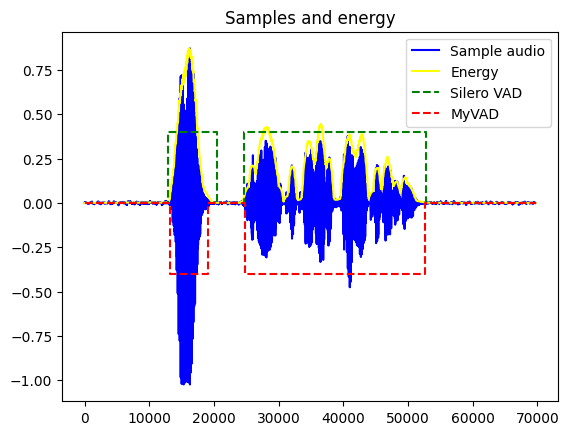

[{'start': 13202, 'end': 19047}, {'start': 24722, 'end': 52541}]

In [ ]:
myvad = MyVAD()
myvad.vad(wave_pathes[102], plot_result=True)

As we can see, in the case where there are two distinct intervals containing voice, our own implementation of Voice Activity Detection (VAD) demonstrates a very good result compared to Silero.

## Evaluation

In [ ]:
from pyannote.core import Annotation, Segment, Timeline
from pyannote.metrics.detection import DetectionErrorRate
import random

metric = DetectionErrorRate()
myvad = MyVAD()
indices = random.sample(range(0, len(wave_pathes) + 1), 1000)

for ind in tqdm(indices):
    file = wave_pathes[ind]
    wav = read_audio(file)
    speech_timestamps = get_speech_timestamps(wav, silero)
    reference = Annotation()
    for speech in speech_timestamps:
      reference[Segment(speech["start"] / SAMPLING_RATE, speech["end"] / SAMPLING_RATE)] = "SPEECH"

    hypothesis = Annotation()
    speech_timestamps_myvad = myvad.vad(file)
    for speech in speech_timestamps_myvad:
      hypothesis[Segment(speech["start"] / SAMPLING_RATE, speech["end"] / SAMPLING_RATE)] = "SPEECH"

    audio_duration = len(wav) / SAMPLING_RATE
    uem = Timeline(segments=[Segment(0, audio_duration)])
    # evaluate its output
    _ = metric(
        reference,      # this is the reference annotation
        hypothesis,     # this is the hypothesized annotation
        uem = uem)

# aggregate the performance over the whole test set
detection_error_rate = abs(metric)
print(f'\nDetection error rate = {detection_error_rate * 100:.1f}%')

  2%|▏         | 23/1000 [00:15<11:02,  1.47it/s]/usr/local/lib/python3.11/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
100%|██████████| 1000/1000 [10:23<00:00,  1.60it/s]


Detection error rate = 4.9%


So, we achieved an error rate of 4.9%, which is a very good result for an no learning-based algorithm. To test its robustness, let’s perform another test, this time using 5 combined recordings as input. This will allow us to evaluate how well the algorithm handles multiple intervals containing speech simultaneously.

In [ ]:
metric = DetectionErrorRate()
myvad = MyVAD()
indices = random.sample(range(0, len(wave_pathes) + 1), 2500)

file_name = "temp.wav"
for ind in tqdm(range(0, 2500, 5)):
    audio1, _ = librosa.load(wave_pathes[ind], sr=SAMPLING_RATE)
    audio2, _ = librosa.load(wave_pathes[ind + 1], sr=SAMPLING_RATE)
    audio3, _ = librosa.load(wave_pathes[ind + 2], sr=SAMPLING_RATE)
    audio4, _ = librosa.load(wave_pathes[ind + 3], sr=SAMPLING_RATE)
    audio5, _ = librosa.load(wave_pathes[ind + 4], sr=SAMPLING_RATE)

    audio = np.concatenate((audio1, audio2, audio3, audio4, audio5))
    sf.write(file_name, data=audio, samplerate=SAMPLING_RATE)

    wav = read_audio(file_name)
    speech_timestamps = get_speech_timestamps(wav, silero)

    reference = Annotation()
    for speech in speech_timestamps:
      reference[Segment(speech["start"] / SAMPLING_RATE, speech["end"] / SAMPLING_RATE)] = "SPEECH"

    hypothesis = Annotation()
    speech_timestamps_myvad = myvad.vad(file_name)
    for speech in speech_timestamps_myvad:
      hypothesis[Segment(speech["start"] / SAMPLING_RATE, speech["end"] / SAMPLING_RATE)] = "SPEECH"

    audio_duration = len(wav) / SAMPLING_RATE
    uem = Timeline(segments=[Segment(0, audio_duration)])
    # evaluate its output
    _ = metric(
        reference,      # this is the reference annotation
        hypothesis,     # this is the hypothesized annotation
        uem = uem)

# aggregate the performance over the whole test set
detection_error_rate = abs(metric)
print(f'\nDetection error rate = {detection_error_rate * 100:.1f}%')

 65%|██████▍   | 324/500 [16:28<09:20,  3.19s/it]/usr/local/lib/python3.11/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 72%|███████▏  | 362/500 [18:15<06:35,  2.86s/it]/usr/local/lib/python3.11/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
100%|██████████| 500/500 [24:16<00:00,  2.91s/it]


Detection error rate = 4.8%


So, algorithm achieved an error rate of 4.8% for concatenated input, which further confirms the robustness of the algorithm.